In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import FunctionTransformer

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Configurations
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize":10,
    "axes.labelsize": 9,
    "xtick.labelsize":8,
    "ytick.labelsize":8
})

RANDOM_STATE =42
TARGET_COL = "SalePrice"

In [3]:
df=pd.read_csv("data (1).csv")

# EDA

In [4]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.000,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.000,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.000,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.000,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.000,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.000,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.000,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.000,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.000,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.000,T

In [5]:
df.shape

(1460, 81)

In [6]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


1. Id

   
Just a serial number for each house. It does not affect price. We remove it.

2. MSSubClass

   
Tells what type of house it is (1 floor, 2 floors, etc.). Different types have different prices.

5. MSZoning


   Shows land type (residential, commercial). Residential areas usually have higher house demand.

7. LotFrontage  


   How much width of the house touches the road. Bigger frontage can increase price.

9. LotArea


Total land size. Bigger land usually means higher price.

11. Street
  
  Type of road (paved or not). Paved roads are better and increase value.

12. Alley
  
  Alley access behind the house. May increase convenience.

13. LotShape
  
  Shape of land (regular or irregular). Regular shape is preferred.

14. LandContour
  
  Flat or uneven land. Flat land is better.

15. Utilities
  
  Basic services like water, electricity. Very important for living.

16. LotConfig
  
  Position of the plot (corner, inside, etc.). Corner plots may cost more.

17. LandSlope
  
  Slope of land. Flat land is more valuable.

18. Neighborhood
  
  Area where the house is located. Very important factor for price.

19. Condition1
 
 Near road, railway, etc. Location conditions affect price.

20. Condition2
 
 Second nearby condition. May affect noise or comfort.

21. BldgType
 
 Type of building (single family, duplex). Single family homes usually cost more.

22. HouseStyle
 
 Design of the house (1 story, 2 story). Style affects demand.

23. OverallQual
 
 Overall quality of materials and finishing. One of the most important features.

24. OverallCond
 
 Overall condition of house. Better condition means higher price.

25. YearBuilt
 
 Year when house was built. New houses usually cost more.

26. YearRemodAdd
 
 Year of last renovation. Recently renovated houses sell at higher price.

27. RoofStyle
 
 Roof design type. Some styles are more attractive.

28. RoofMatl
 
 Roof material. Strong material increases value.

29. Exterior1st
 
 Main outside material of house.

30. Exterior2nd
 
 Second outside material.

31. MasVnrType
 
 Type of wall covering like brick or stone.

32. MasVnrArea
 
 Area covered with stone/brick. Larger area may increase value.

33. ExterQual
 
 Quality of outside material. Higher quality increases price.

34. ExterCond
 
 Condition of outside walls. Good condition increases value.

35. Foundation
 
 Type of base of the house. Strong foundation is better.

36. BsmtQual
  
  Quality of basement height. Good basement increases value.

37. BsmtCond
 
 Condition of basement.

38. BsmtExposure
 
 Does basement have windows or outside access.

39. BsmtFinType1
 
 Type of finished basement area.

40. BsmtFinSF1
 
 Size of finished basement area.

41. BsmtFinType2
 
 Second type of finished basement area.

42. BsmtFinSF2
 
 Size of second finished basement area.

43. BsmtUnfSF
 
 Unfinished basement area.

44. TotalBsmtSF
 
 Total basement size. Bigger basement increases price.

45. Heating
 
 Type of heating system.

46. HeatingQC
 
 Quality of heating system.

47. CentralAir
 
 Does house have AC or not. AC increases value.

48. Electrical
 
 Type of electrical system.

49. 1stFlrSF
 
 First floor area size.

50. 2ndFlrSF
 
 Second floor area size.

51. LowQualFinSF
 
 Low quality finished area. May reduce value.

52. GrLivArea
 
 Total living area above ground. Very important feature.

53. BsmtFullBath
 
 Number of full bathrooms in basement.

54. BsmtHalfBath
 
 Number of half bathrooms in basement.

55. FullBath
 
Number of full bathrooms. More bathrooms increase price.

56. HalfBath
 
 Number of half bathrooms.

57. BedroomAbvGr
 
 Number of bedrooms.

58. KitchenAbvGr
 
 Number of kitchens.

59. KitchenQual
 
 Kitchen quality. Very important for price.

60. TotRmsAbvGrd
 
 Total rooms above ground.

61. Functional
 
 Is house fully functional or needs repair.

62. Fireplaces
 
  
  Number of fireplaces. Adds beauty and value.

63. FireplaceQu
 
  
  Quality of fireplace.

64. GarageType
 
  
  Type of garage (attached/detached).

65. GarageYrBlt
 
  
  Year garage was built.

66. GarageFinish
 
  
  Is garage finished inside or not.

67. GarageCars
 
  
  How many cars can fit. Very important feature.

68. GarageArea
 
  
  Size of garage. Bigger garage increases value.

69. GarageQual
 
 Garage quality.

70. GarageCond
 
 Garage condition.

71. PavedDrive
 
 Is driveway paved or not.

72. WoodDeckSF
 
 Size of wooden deck.

73. OpenPorchSF
 
 Open porch size.

74. EnclosedPorch
 
 Closed porch size.

75. 3SsnPorch
 
 Three season porch size.

76. ScreenPorch
 
 Screened porch size.

77. PoolArea
 
 Size of pool. Luxury feature.

78. PoolQC
 
 Quality of pool.

79. Fence
 
 Fence quality.

80. MiscFeature
 
 Other extra feature like shed.

81. MiscVal
 
 Value of extra feature.

82. MoSold
 
 Month when house was sold.

83. YrSold
 
 Year when house was sold.

84. SaleType
 
 Type of sale (normal, auction, etc.).

85. SaleCondition
 
 Condition of sale (normal, abnormal).

86. SalePrice
 
 Final selling price of house. This is the target variable.


In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
num_cols =df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

In [10]:
num_cols

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [11]:
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [12]:
TARGET_COL

'SalePrice'

In [13]:

# to see all null value columns only
df.isnull().sum().loc[lambda x : x>0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [14]:
df.isnull().sum().sum()

np.int64(7829)

In [15]:
# check the presence of encoded missing values
for col in df.columns:
    print(f"n/columns: {col}")
    print(df[col].value_counts(dropna=False).head(20))

n/columns: Id
Id
1      1
982    1
980    1
979    1
978    1
977    1
976    1
975    1
974    1
973    1
972    1
971    1
970    1
969    1
968    1
967    1
966    1
965    1
964    1
963    1
Name: count, dtype: int64
n/columns: MSSubClass
MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64
n/columns: MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
n/columns: LotFrontage
LotFrontage
NaN        259
60.000     143
70.000      70
80.000      69
50.000      57
75.000      53
65.000      44
85.000      40
78.000      25
90.000      23
21.000      23
64.000      19
24.000      19
68.000      19
73.000      18
55.000      17
72.000      17
63.000      17
79.000      17
100.000     16
Name: count, dtype: int64
n/columns: LotArea
LotArea
7200     25
9600     24
6000  

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.000,730.500,421.610,1.000,365.750,730.500,1095.250,1460.000
MSSubClass,1460.000,56.897,42.301,20.000,20.000,50.000,70.000,190.000
LotFrontage,1201.000,70.050,24.285,21.000,59.000,69.000,80.000,313.000
LotArea,1460.000,10516.828,9981.265,1300.000,7553.500,9478.500,11601.500,215245.000
OverallQual,1460.000,6.099,1.383,1.000,5.000,6.000,7.000,10.000
OverallCond,1460.000,5.575,1.113,1.000,5.000,5.000,6.000,9.000
YearBuilt,1460.000,1971.268,30.203,1872.000,1954.000,1973.000,2000.000,2010.000
YearRemodAdd,1460.000,1984.866,20.645,1950.000,1967.000,1994.000,2004.000,2010.000
MasVnrArea,1452.000,103.685,181.066,0.000,0.000,0.000,166.000,1600.000
BsmtFinSF1,1460.000,443.640,456.098,0.000,0.000,383.500,712.250,5644.000


## Data visulization

<function matplotlib.pyplot.show(close=None, block=None)>

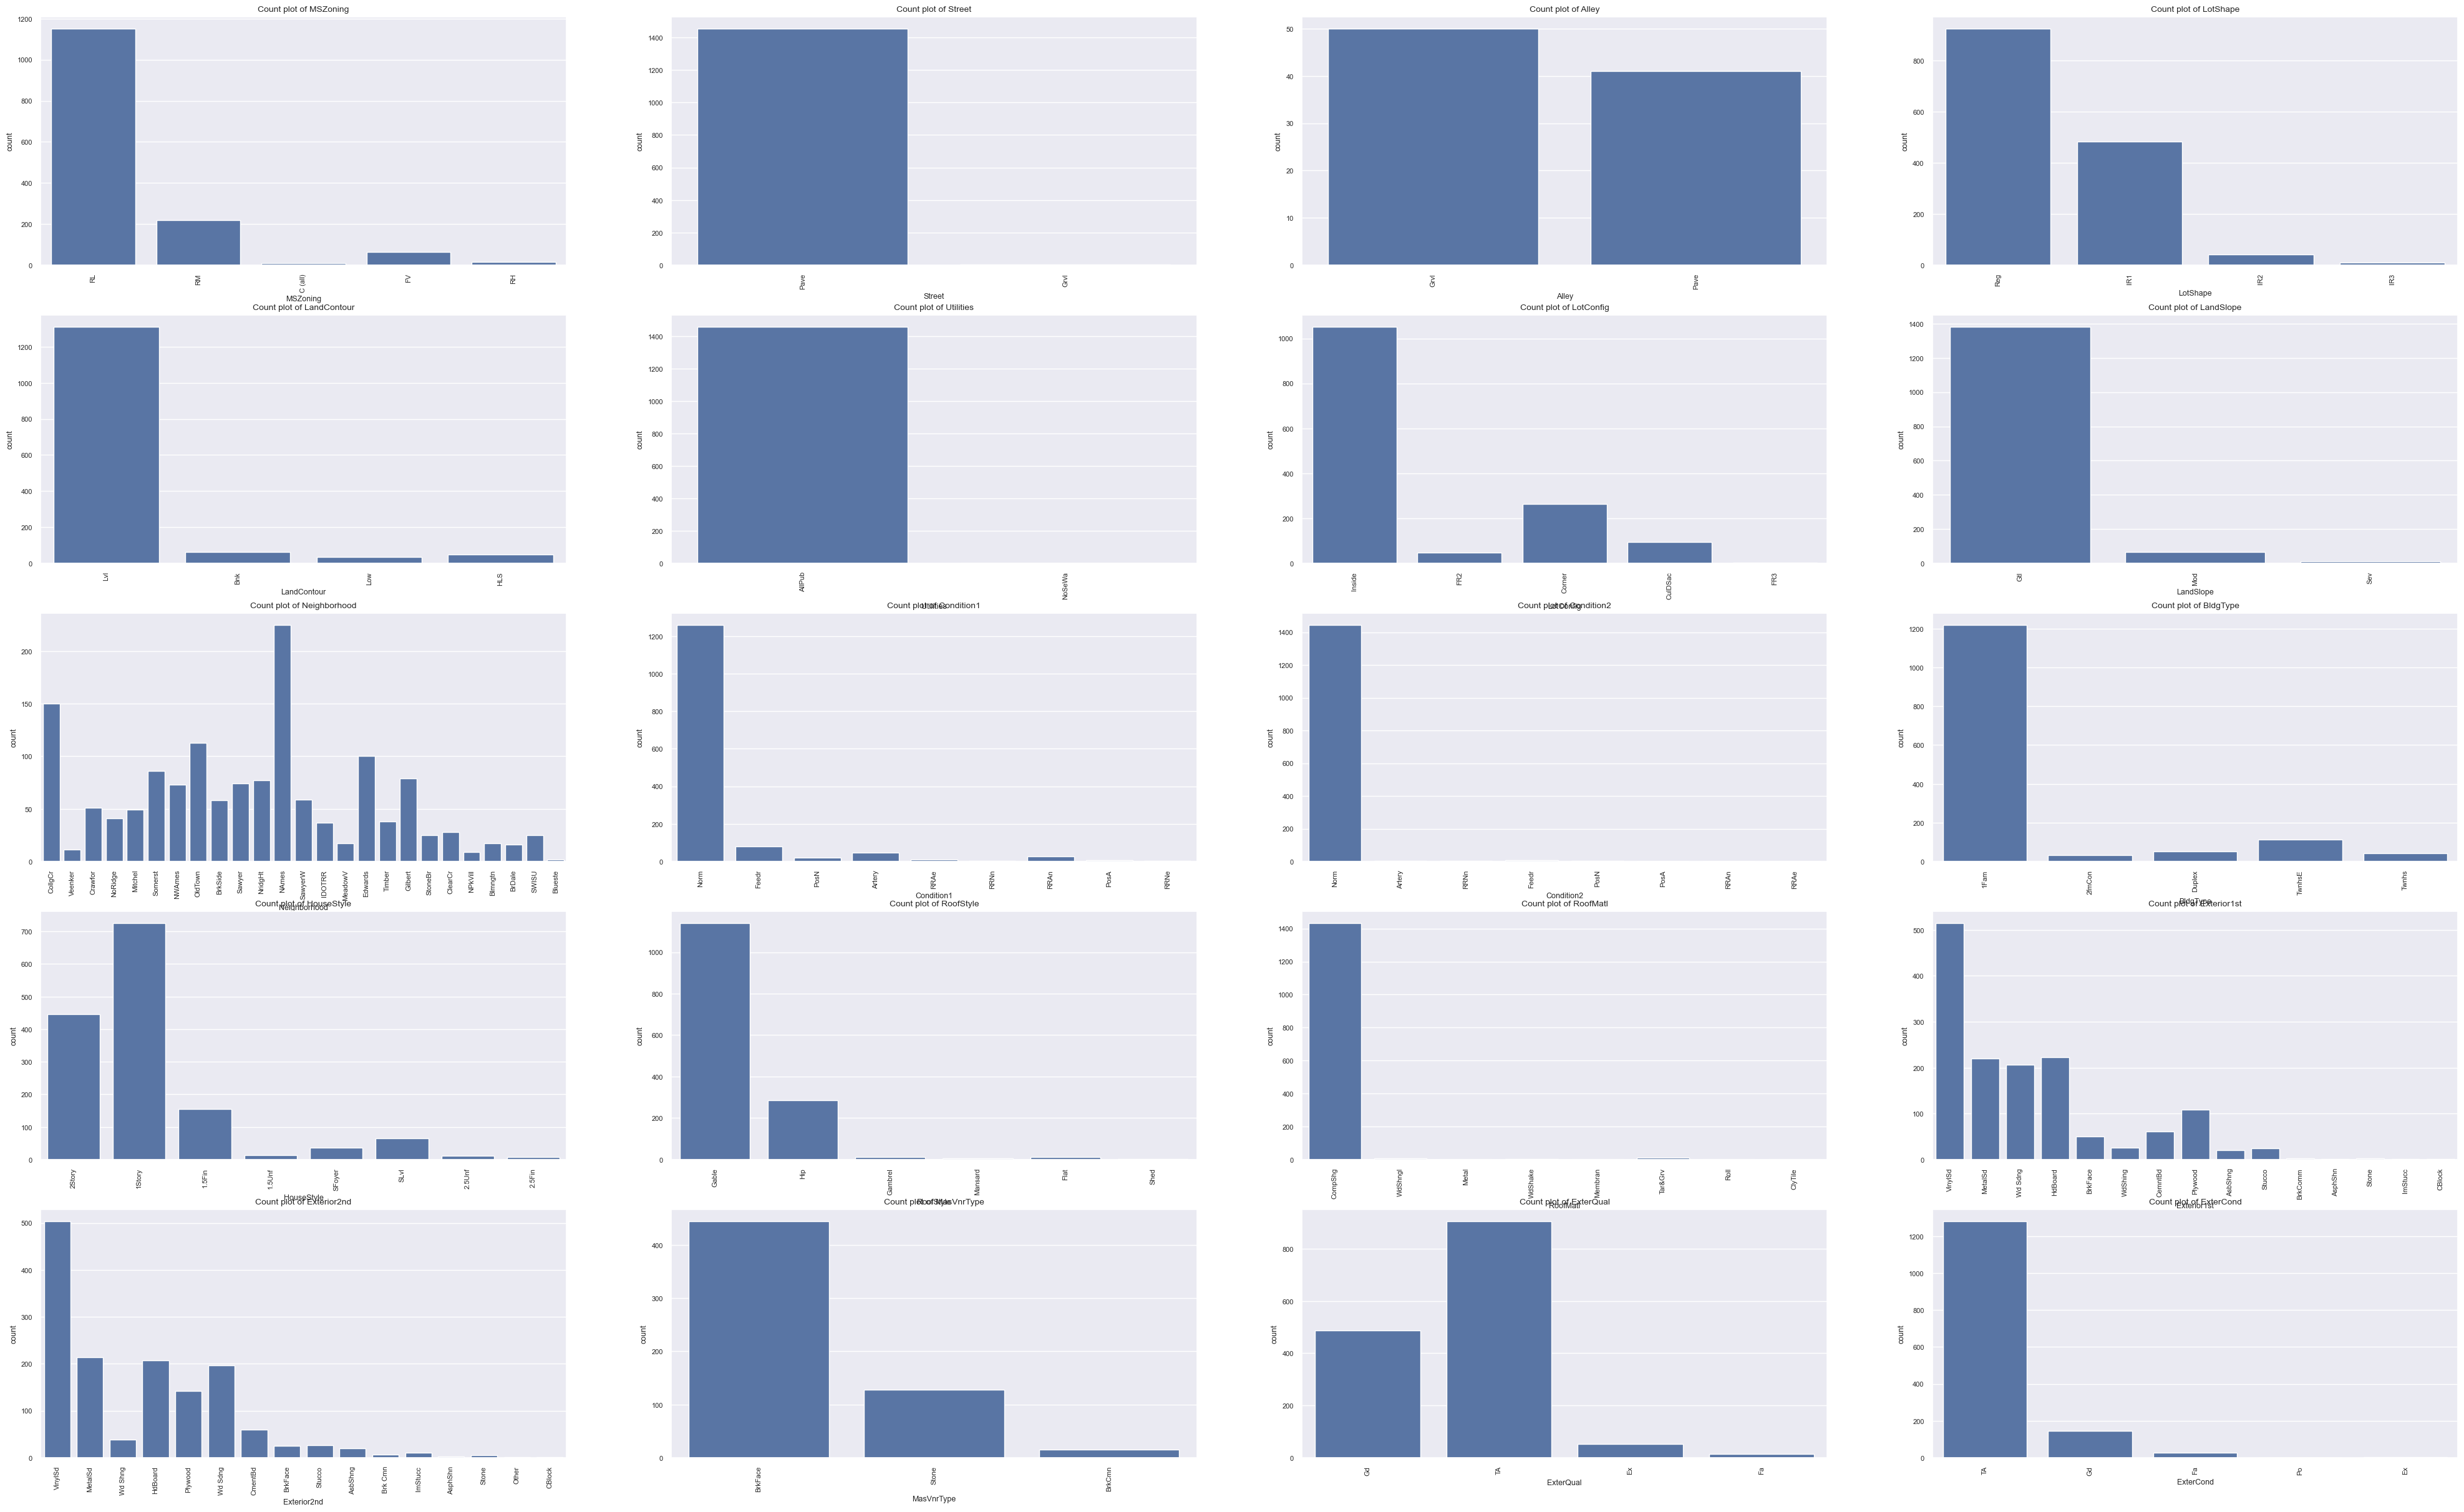

In [17]:
# count pLot for categorical columns
plt.figure(figsize=(50,30))
plot=1
for col in cat_cols:
    if plot<=20:
        plt.subplot(5,4,plot)
        sns.countplot(x=df[col])
        plt.title(f"Count plot of {col}")
        plt.xticks(rotation=90)
        plot+=1
plt.tight_layout
plt.show
    

In [18]:
for col in cat_cols:
    print(df[col].value_counts())

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
Street
Pave    1454
Grvl       6
Name: count, dtype: int64
Alley
Grvl    50
Pave    41
Name: count, dtype: int64
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker   

<function matplotlib.pyplot.show(close=None, block=None)>

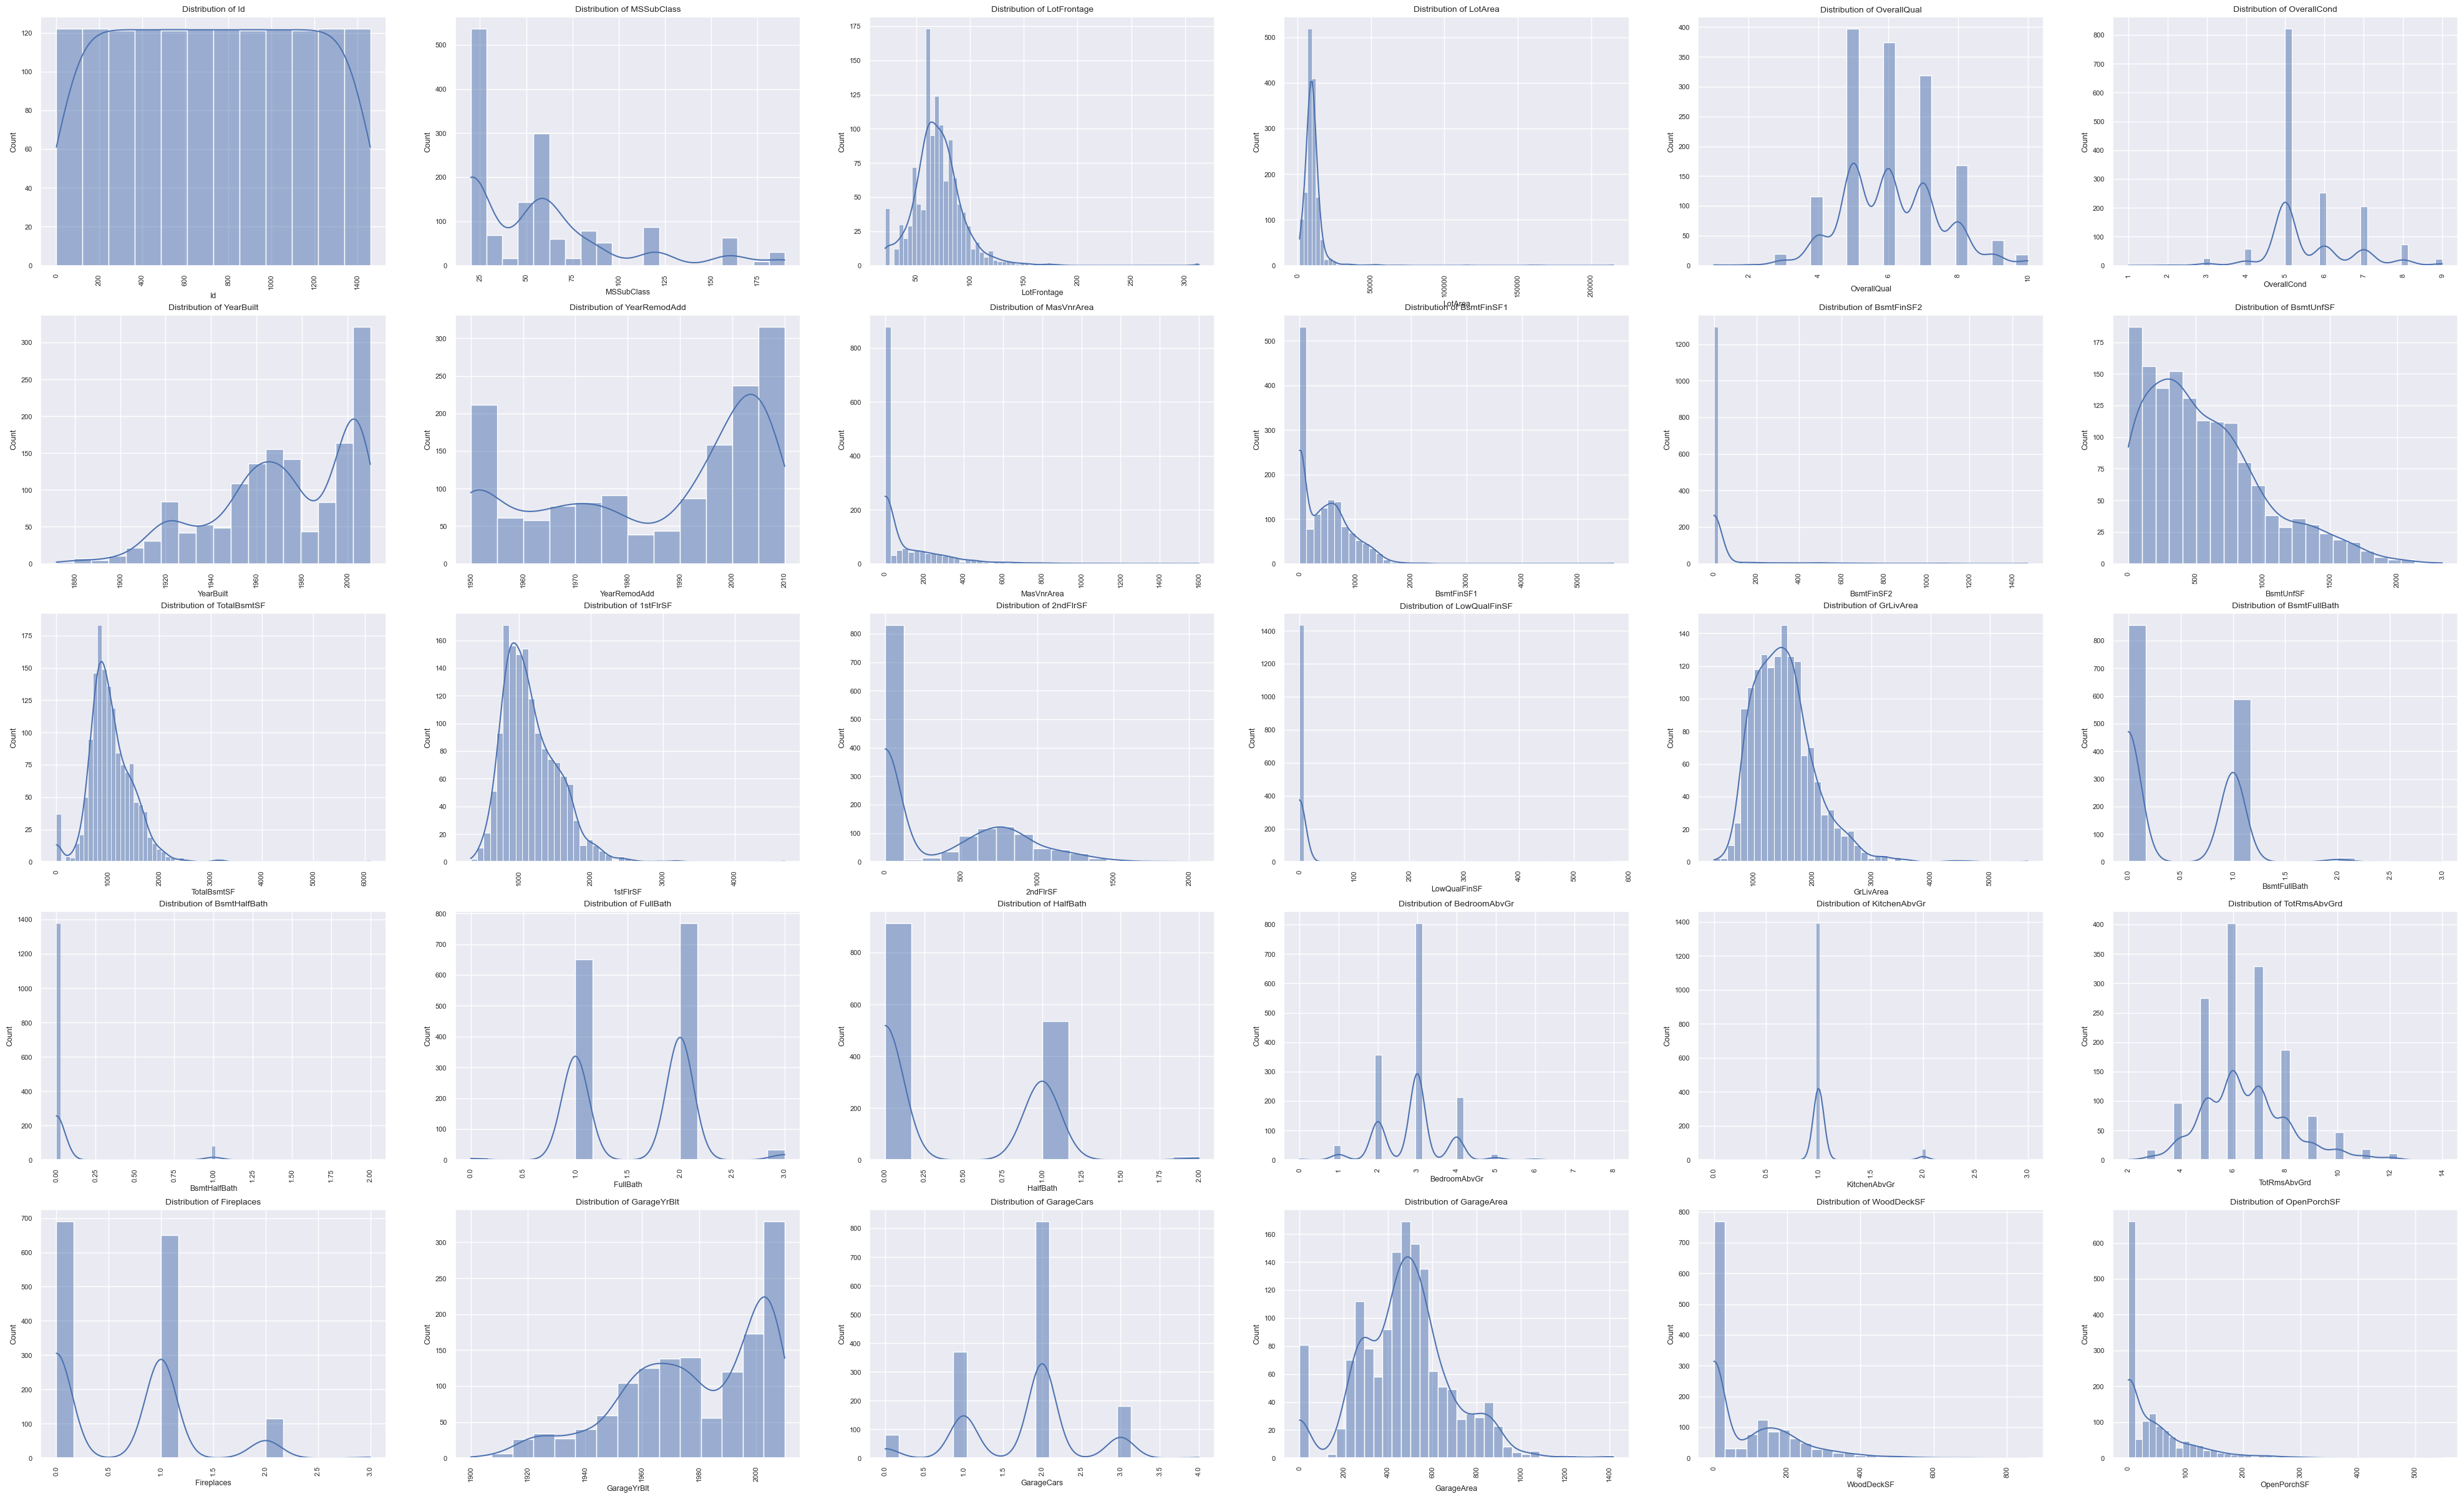

In [19]:
# Histogram for Numric columns
plt.figure(figsize=(50,30))
plot=1
for col in num_cols:
    if plot<=30:
        plt.subplot(5,6,plot)
        sns.histplot(x=df[col],kde=True)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=90)
        plot+=1
plt.tight_layout
plt.show

<Axes: xlabel='SalePrice', ylabel='Count'>

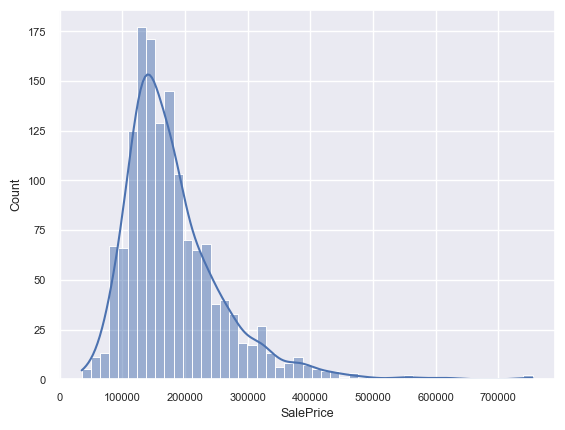

In [20]:
sns.histplot(df[TARGET_COL],kde=True)

<function matplotlib.pyplot.show(close=None, block=None)>

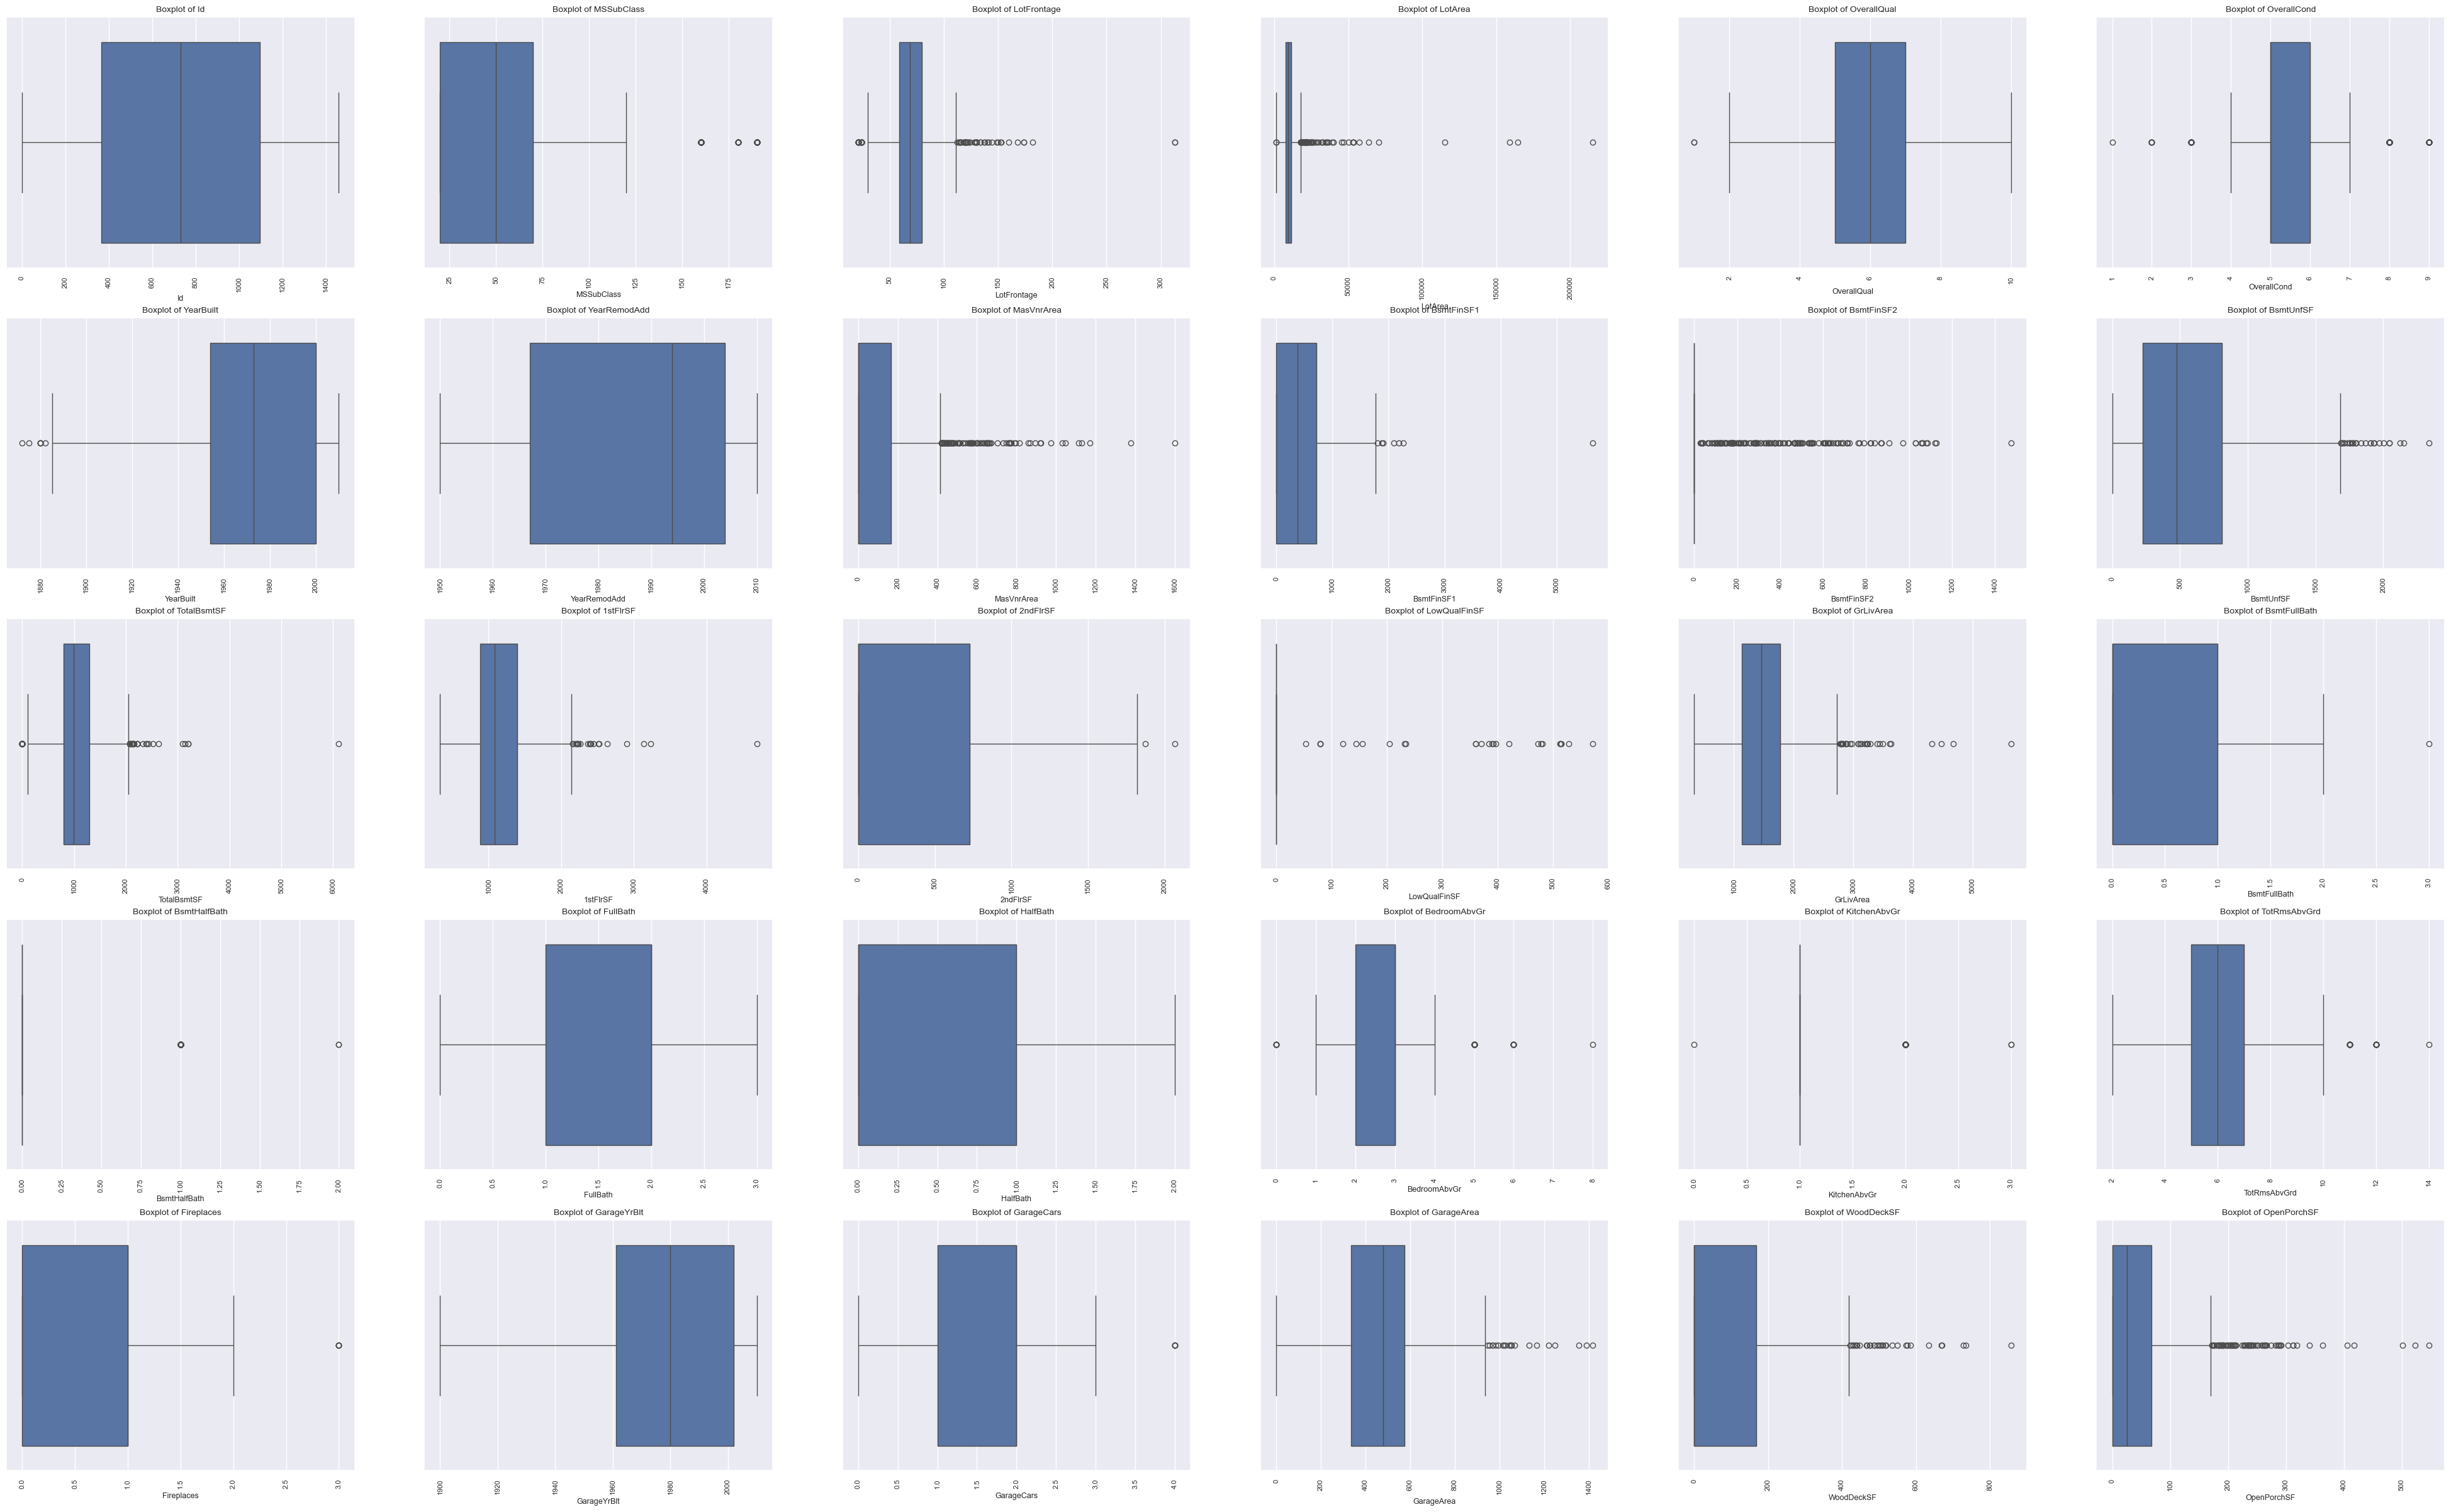

In [21]:
plt.figure(figsize=(50,30))
plot=1
for col in num_cols:
    if plot<=30:
        plt.subplot(5,6,plot)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.xticks(rotation=90)
        plot+=1
plt.tight_layout
plt.show

Text(0.5, 1.0, 'Correlation Heatmap')

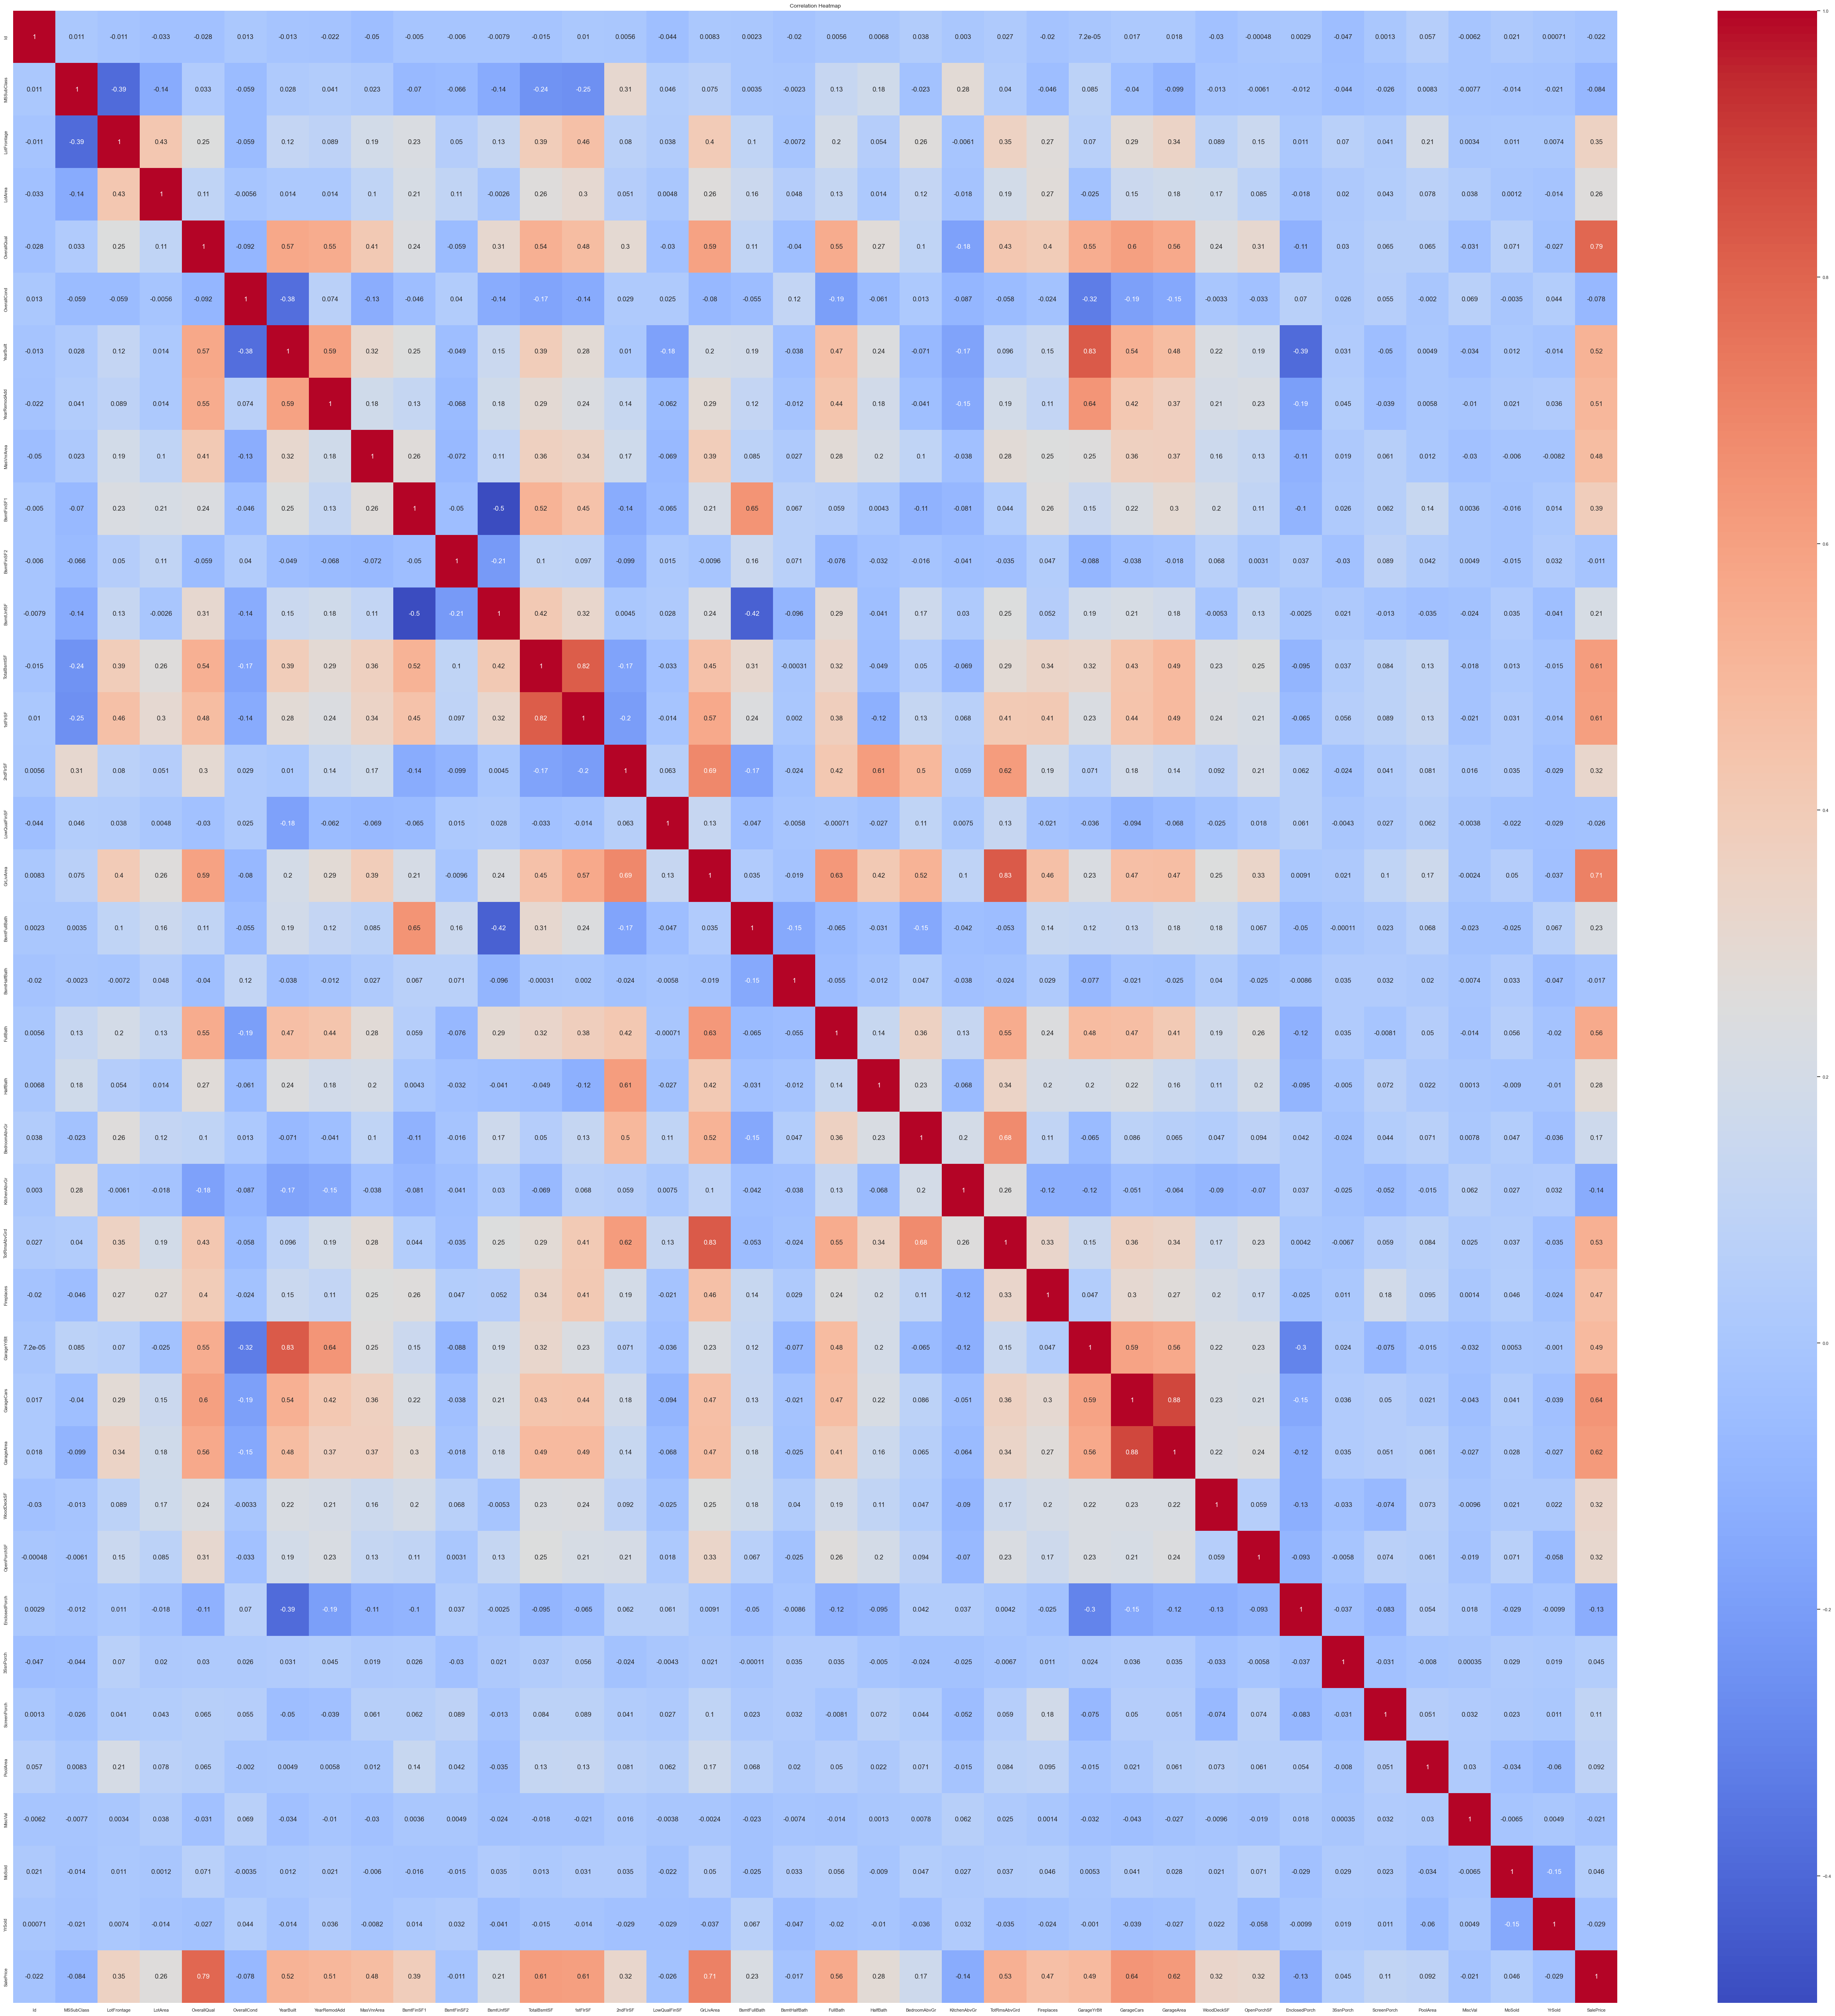

In [22]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(65,65))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")


In [23]:
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print(f"\nCorrelation with taget")
print(corr_with_target)


Correlation with taget
SalePrice        1.000
OverallQual      0.791
GrLivArea        0.709
GarageCars       0.640
GarageArea       0.623
TotalBsmtSF      0.614
1stFlrSF         0.606
FullBath         0.561
TotRmsAbvGrd     0.534
YearBuilt        0.523
YearRemodAdd     0.507
GarageYrBlt      0.486
MasVnrArea       0.477
Fireplaces       0.467
BsmtFinSF1       0.386
LotFrontage      0.352
WoodDeckSF       0.324
2ndFlrSF         0.319
OpenPorchSF      0.316
HalfBath         0.284
LotArea          0.264
BsmtFullBath     0.227
BsmtUnfSF        0.214
BedroomAbvGr     0.168
ScreenPorch      0.111
PoolArea         0.092
MoSold           0.046
3SsnPorch        0.045
BsmtFinSF2      -0.011
BsmtHalfBath    -0.017
MiscVal         -0.021
Id              -0.022
LowQualFinSF    -0.026
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


In [24]:
df.corr(numeric_only=True)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000,0.011,-0.011,-0.033,-0.028,0.013,-0.013,-0.022,-0.050,-0.005,-0.006,-0.008,-0.015,0.010,0.006,-0.044,0.008,0.002,-0.020,0.006,0.007,0.038,0.003,0.027,-0.020,0.000,0.017,0.018,-0.030,-0.000,0.003,-0.047,0.001,0.057,-0.006,0.021,0.001,-0.022
MSSubClass,0.011,1.000,-0.386,-0.140,0.033,-0.059,0.028,0.041,0.023,-0.070,-0.066,-0.141,-0.239,-0.252,0.308,0.046,0.075,0.003,-0.002,0.132,0.177,-0.023,0.282,0.040,-0.046,0.085,-0.040,-0.099,-0.013,-0.006,-0.012,-0.044,-0.026,0.008,-0.008,-0.014,-0.021,-0.084
LotFrontage,-0.011,-0.386,1.000,0.426,0.252,-0.059,0.123,0.089,0.193,0.234,0.050,0.133,0.392,0.457,0.080,0.038,0.403,0.101,-0.007,0.199,0.054,0.263,-0.006,0.352,0.267,0.070,0.286,0.345,0.089,0.152,0.011,0.070,0.041,0.206,0.003,0.011,0.007,0.352
LotArea,-0.033,-0.140,0.426,1.000,0.106,-0.006,0.014,0.014,0.104,0.214,0.111,-0.003,0.261,0.299,0.051,0.005,0.263,0.158,0.048,0.126,0.014,0.120,-0.018,0.190,0.271,-0.025,0.155,0.180,0.172,0.085,-0.018,0.020,0.043,0.078,0.038,0.001,-0.014,0.264
OverallQual,-0.028,0.033,0.252,0.106,1.000,-0.092,0.572,0.551,0.412,0.240,-0.059,0.308,0.538,0.476,0.295,-0.030,0.593,0.111,-0.040,0.551,0.273,0.102,-0.184,0.427,0.397,0.548,0.601,0.562,0.239,0.309,-0.114,0.030,0.065,0.065,-0.031,0.071,-0.027,0.791
OverallCond,0.013,-0.059,-0.059,-0.006,-0.092,1.000,-0.376,0.074,-0.128,-0.046,0.040,-0.137,-0.171,-0.144,0.029,0.025,-0.080,-0.055,0.118,-0.194,-0.061,0.013,-0.087,-0.058,-0.024,-0.324,-0.186,-0.152,-0.003,-0.033,0.070,0.026,0.055,-0.002,0.069,-0.004,0.044,-0.078
YearBuilt,-0.013,0.028,0.123,0.014,0.572,-0.376,1.000,0.593,0.316,0.250,-0.049,0.149,0.391,0.282,0.010,-0.184,0.199,0.188,-0.038,0.468,0.243,-0.071,-0.175,0.096,0.148,0.826,0.538,0.479,0.225,0.189,-0.387,0.031,-0.050,0.005,-0.034,0.012,-0.014,0.523
YearRemodAdd,-0.022,0.041,0.089,0.014,0.551,0.074,0.593,1.000,0.180,0.128,-0.068,0.181,0.291,0.240,0.140,-0.062,0.287,0.119,-0.012,0.439,0.183,-0.041,-0.150,0.192,0.113,0.642,0.421,0.372,0.206,0.226,-0.194,0.045,-0.039,0.006,-0.010,0.021,0.036,0.507
MasVnrArea,-0.050,0.023,0.193,0.104,0.412,-0.128,0.316,0.180,1.000,0.265,-0.072,0.114,0.364,0.345,0.175,-0.069,0.391,0.085,0.027,0.277,0.201,0.103,-0.038,0.281,0.249,0.253,0.364,0.373,0.160,0.126,-0.110,0.019,0.061,0.012,-0.030,-0.006,-0.008,0.477
BsmtFinSF1,-0.005,-0.070,0.234,0.214,0.240,-0.046,0.250,0.128,0.265,1.000,-0.050,-0.495,0.522,0.446,-0.137,-0.065,0.208,0.649,0.067,0.059,0.004,-0.107,-0.081,0.044,0.260,0.153,0.224,0.297,0.204,0.112,-0.102,0.026,0.062,0.140,0.004,-0.016,0.014,0.386


In [25]:
corr_matrix=df.corr(numeric_only=True)

In [26]:
upper =corr_matrix.where(np.triu(np.ones(corr.shape),k=1).astype(bool))

high_corr = [column for column in upper.columns if any (upper[column]>0.85)]


high_corr

['GarageArea']

In [27]:
# 1. Drop unnecessary columns
drop_cols = ["Id", "Alley", "PoolQC", "Fence", "MiscFeature", "Street", "Utilities", "GarageArea"]
df = df.drop(columns=drop_cols)

## EDA insight
* Target variable SalePrice is right-skewed with presence of outliers.
* Features like "LotArea", "GrLivArea", "TotalBsmtSF" are highly skewed.
* Columns such as "PoolArea", "3SsnPorch", "LowQualFinSF" have mostly zero values.
* High missing values observed in "LotFrontage", "GarageYrBlt", "Alley", "PoolQC".
* Strong predictors include "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF".

## Preprocessing needs to apply
* Drop unnecessary columns: ["Id", "Alley", "PoolQC", "Fence", "MiscFeature", "Street", "Utilities", "GarageArea"].
* 
* Impute missing values in numerical columns like ["LotFrontage", "GarageYrBlt", "MasVnrArea"] using median.
* 
* Fill missing values with "None" in categorical columns where absence is meaningful, such as ["MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond"].
* 
* Apply log transformation to skewed numerical features: ["LotArea", "GrLivArea", "TotalBsmtSF"], and also transform the target "SalePrice".
* 
* Encode ordinal categorical columns ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "FireplaceQu", "GarageFinish", "GarageQual", "GarageCond"] using Ordinal Encoding.
* 
* Encode nominal categorical columns ["MSZoning", "LotShape", "LandContour", "LotConfig", "LandSlope", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", "CentralAir", "Electrical", "GarageType", "PavedDrive", "SaleType", "SaleCondition"] using OneHotEncoder, then scale numerical features with StandardScaler inside the pipeline.* 

## Data preprocessing

In [28]:
X = df.drop(columns=[TARGET_COL])
y = np.log1p(df[TARGET_COL])   # target log transform

In [95]:
X.columns


Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'LotShape',
       'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch

In [30]:
y.head()

0   12.248
1   12.109
2   12.317
3   11.849
4   12.429
Name: SalePrice, dtype: float64

In [31]:
# Train test split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [32]:
print("Train shape:",X_train.shape)
print("Test shape:",X_test.shape)

Train shape: (1168, 72)
Test shape: (292, 72)


## Preprocessing Pipeline

In [33]:
numerical_feature= X.select_dtypes(include=[np.number]).columns.tolist()

numerical_feature

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [34]:
categorical_feature= X.select_dtypes(exclude=[np.number]).columns.tolist()
categorical_feature

['MSZoning',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'SaleType',
 'SaleCondition']

In [35]:
ordinal_cols = [
    "ExterQual","ExterCond",
    "BsmtQual","BsmtCond","BsmtExposure",
    "BsmtFinType1","BsmtFinType2",
    "HeatingQC","KitchenQual",
    "FireplaceQu",
    "GarageFinish","GarageQual","GarageCond"
]

ordinal_categories = [
    ["Po", "Fa", "TA", "Gd", "Ex"],                      
    ["Po", "Fa", "TA", "Gd", "Ex"],                    
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],           
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],           
    ["None", "No", "Mn", "Av", "Gd"],                    
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],   
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],   
    ["Po", "Fa", "TA", "Gd", "Ex"],                    
    ["Po", "Fa", "TA", "Gd", "Ex"],                      
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],              
    ["None", "Unf", "RFn", "Fin"],                        
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],             
    ["None", "Po", "Fa", "TA", "Gd", "Ex"]              
]

nominal_cols = [col for col in categorical_feature if col not in ordinal_cols]



# 4. Log columns for outlier/skew handling
log_cols = ["LotArea", "GrLivArea", "TotalBsmtSF"]
normal_num_cols = [col for col in numerical_feature if col not in log_cols]

In [36]:
## Numeric feature preprocessing steps
numeric_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)
## Categorical Nominal feature preprocessing steps
nominal_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="constant",fill_value="None")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]
)

#Categorical Ordinal feature preprocessing steps


ordinal_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="constant",fill_value="None")),
        ("encoder",OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value",
    unknown_value=-1))
    ]
)

# skewed numerical columns -> impute -> log -> scale
log_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler())
    ]
)


In [37]:
# Preprocessing Pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num",numeric_transformer,numerical_feature),
        ("Nominal",nominal_transformer,nominal_cols),
        ("ordinal",ordinal_transformer,ordinal_cols),
        ("log_num", log_numeric_transformer, log_cols)
    ]
)

## Baseline Model 

In [38]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",LinearRegression())
    ]
)

In [39]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFi...
                                                   'BsmtFinType2', 'HeatingQC',
                                                   'KitchenQual', 'FireplaceQu',
                                                   'GarageFinish', 'GarageQual',
                                                   'GarageCond']),
                                                 ('log_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotArea', 'GrLivArea',
                                                   'TotalBsmtSF'])])),
                ('model', LinearRegression())])

## Evaluation of Our Baseline Model

In [40]:
test_baseline_pred = baseline_pipe.predict(X_test)
train_baseline_pred = baseline_pipe.predict(X_train)


In [41]:
train_baseline_rmse = root_mean_squared_error(y_train,train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train,train_baseline_pred)
train_baseline_r2 = r2_score(y_train,train_baseline_pred)

In [42]:
train_baseline_pred[:5]

array([11.86283948, 12.07701842, 11.42593853, 12.04295957, 11.94412138])

In [43]:
y_train[:5]

254    11.884
1066   12.090
638    11.350
799    12.073
380    11.752
Name: SalePrice, dtype: float64

In [44]:
print("\n=== TRAIN BASELINE METRICS (LinearRegression)===")
print(f"RMSE:{train_baseline_rmse:.3f}")
print(f"MAE:{train_baseline_mae:.3f}")
print(f"R2:{train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression)===
RMSE:0.093
MAE:0.064
R2:0.944


In [45]:
test_baseline_rmse = root_mean_squared_error(y_test,test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test,test_baseline_pred)
test_baseline_r2 = r2_score(y_test,test_baseline_pred)

In [46]:
print("\n=== TEST BASELINE METRICS (LinearRegression)===")
print(f"RMSE:{test_baseline_rmse:.3f}")
print(f"MAE:{test_baseline_mae:.3f}")
print(f"R2:{test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression)===
RMSE:0.125
MAE:0.086
R2:0.916


## Model selection and Optimization

In [47]:
# models to try
models={
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(random_state=42),
    "Lasso":Lasso(random_state=42,max_iter=10000),
    "RandomForest":RandomForestRegressor(),
    "HistGB":HistGradientBoostingRegressor()
}

In [48]:
k=5
cv=KFold(n_splits=k,shuffle=True,random_state=42)


In [49]:
scoring={
    "rmse":"neg_root_mean_squared_error",
    "mae":"neg_mean_absolute_error",
    "r2": "r2"
}

In [50]:
rows=[]
for name,model in models.items():
    pipe=Pipeline(
        steps=[
            ("preprocess",preprocess),
            ("model",model)
        ]
    )
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    rows.append({
        "model":name,
        "cv_rmse":-scores["test_rmse"].mean(),
        "cv_mae":-scores["test_mae"].mean(),
        "cv_r2":scores["test_r2"].mean(),
        
    })
    # sort based on lowest rmse value
    cv_results=pd.DataFrame(rows).sort_values("cv_rmse")
    print("=== cv Model Comparison")
    print(cv_results)

=== cv Model Comparison
              model  cv_rmse  cv_mae  cv_r2
0  LinearRegression    0.146   0.089  0.859
=== cv Model Comparison
              model  cv_rmse  cv_mae  cv_r2
1             Ridge    0.135   0.087  0.880
0  LinearRegression    0.146   0.089  0.859
=== cv Model Comparison
              model  cv_rmse  cv_mae  cv_r2
1             Ridge    0.135   0.087  0.880
0  LinearRegression    0.146   0.089  0.859
2             Lasso    0.390   0.303 -0.001
=== cv Model Comparison
              model  cv_rmse  cv_mae  cv_r2
1             Ridge    0.135   0.087  0.880
0  LinearRegression    0.146   0.089  0.859
3      RandomForest    0.146   0.100  0.860
2             Lasso    0.390   0.303 -0.001


  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

=== cv Model Comparison
              model  cv_rmse  cv_mae  cv_r2
4            HistGB    0.131   0.089  0.886
1             Ridge    0.135   0.087  0.880
0  LinearRegression    0.146   0.089  0.859
3      RandomForest    0.146   0.100  0.860
2             Lasso    0.390   0.303 -0.001


In [51]:
# sort based on lowest rmse value
cv_results=pd.DataFrame(rows).sort_values("cv_rmse")
print("=== Cv Model Comparison ===")
print(cv_results)

=== Cv Model Comparison ===
              model  cv_rmse  cv_mae  cv_r2
4            HistGB    0.131   0.089  0.886
1             Ridge    0.135   0.087  0.880
0  LinearRegression    0.146   0.089  0.859
3      RandomForest    0.146   0.100  0.860
2             Lasso    0.390   0.303 -0.001


## Hyper Parameter Tunning


In [52]:
hgb_pipe = Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",HistGradientBoostingRegressor(random_state=42))
    ]
)

In [57]:
# hyperparameter combination
param_grid={
    "model__learning_rate":[0.03,0.05,0.1],
    "model__max_depth":[None,3,6],
    "model__max_leaf_nodes":[15,31,63],
    "model__min_samples_leaf":[20,50,100],
    "model__l2_regularization":[0.0,0.1,1.0]
}

In [58]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

In [60]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MSSubClass',
                                                                          'LotFrontage',
                                                                          'LotArea',
                                                                          'OverallQual',
                                                                          'OverallCond',
                                                                          'YearBuilt',
                                                                          'YearRemodAdd',
                                                                          'MasVnrArea',
                                                                          'BsmtFinSF1...
                                                                         ['LotArea',
                                                                          'GrLivArea',
                                                                          'TotalBsmtSF'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [61]:
print("\m=== Tuned HistGB (CV)===")
print("Best CV Rmse:",-grid.best_score_)
print("Best params",grid.best_params_)

\m=== Tuned HistGB (CV)===
Best CV Rmse: 0.1285678018365208
Best params {'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 20}


In [62]:
grid.best_score_

np.float64(-0.1285678018365208)

## Retrain with best model

In [67]:
hgb_best = Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",HistGradientBoostingRegressor(
            l2_regularization = 1.0,
            learning_rate =0.1, 
            max_depth =None, 
            max_leaf_nodes =15, 
            min_samples_leaf =20
        ))
    ]
)

In [68]:
# train best model on entire trianing data (can also be done with refit= True in grid search)
hgb_best.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFi...
                                                   'KitchenQual', 'FireplaceQu',
                                                   'GarageFinish', 'GarageQual',
                                                   'GarageCond']),
                                                 ('log_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotArea', 'GrLivArea',
                                                   'TotalBsmtSF'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=1.0,
                                               max_leaf_nodes=15))])

## Final Evalution 

In [70]:
train_final_pred= hgb_best.predict(X_train)
train_final_rsme=root_mean_squared_error(y_train,train_final_pred)
train_final_mae= mean_absolute_error(y_train,train_final_pred)
train_final_r2=r2_score(y_train,train_final_pred)

print("\n=== Final Model(Tuned HGB) Train Performance===")
print(f"RMSE:{train_final_rsme:.3f}"),
print(f"MAE:{train_final_mae:.3}"),
print(f"r2:{train_final_r2:.3f}")


=== Final Model(Tuned HGB) Train Performance===
RMSE:0.064
MAE:0.0436
r2:0.973


In [72]:
test_final_pred= hgb_best.predict(X_test)
test_final_rsme=root_mean_squared_error(y_test,test_final_pred)
test_final_mae= mean_absolute_error(y_test,test_final_pred)
test_final_r2=r2_score(y_test,test_final_pred)

print("\n=== Final Model(Tuned HGB) Train Performance===")
print(f"RMSE:{test_final_rsme:.3f}"),
print(f"MAE:{test_final_mae:.3f}"),
print(f"r2:{test_final_r2:.3f}")


=== Final Model(Tuned HGB) Train Performance===
RMSE:0.137
MAE:0.089
r2:0.899


In [73]:
print("numpy",np.__version__)
print("pandas",pd.__version__)
print("sklearn",pd.__version__)

numpy 2.3.4
pandas 2.2.3
sklearn 2.2.3


In [78]:
import pickle

# save
model = grid.best_estimator_
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

# load
with open("house_price_model.pkl", "rb") as f:
    load_model = pickle.load(f)

In [81]:
load_model= pickle.load(open("house_price_model.pkl",'rb'))

In [87]:
load_model.predict(X_test.head(5))

array([11.86339985, 12.73907927, 11.67355684, 11.97217572, 12.67080121])

In [88]:
y_test.head(5)

892    11.948
1105   12.692
413    11.653
522    11.977
1036   12.662
Name: SalePrice, dtype: float64

In [97]:
import joblib

joblib.dump(model, "house_price_model.joblib")

['house_price_model.joblib']